## Key Question

Given that different rooms may exhibit similar thermal parameters,
where should we prioritize interventions to achieve the greatest energy savings?

Rather than focusing only on model parameters, we shift our attention to:

- Actual heat loss behavior over time
- Environmental exposure (temperature and solar gains)
- Cumulative energy impact

This allows us to move from *modeling* to *decision-making*.

### Load & Setup (Code)

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [25]:
# Load sample data
DATA_PATH = "../data/sample/PreliminaryAnalysis.csv"
df_raw = pd.read_csv(DATA_PATH)

In [26]:
# Import dataset from csv 
min_date = pd.to_datetime('2026-02-25 00:00:00')
max_date = pd.to_datetime('2026-03-02 23:00:00')
df_raw['time'] = pd.to_datetime(df_raw['time'])
df_filtered = df_raw.loc[(df_raw['time'] >= min_date) & (df_raw['time'] <= max_date)]
df_filtered = df_filtered.set_index("time")

In [27]:
def simulate_first_order_with_dynamic_solar(
    T0, 
    Tout_local_series,
    Tout_north_series,
    Tout_south_series,
    k,
    alpha,
    dt=1.0
):
    """
    First-order thermal model with dynamic solar proxy:
    
    T_{t+1} = T_t + [-k*(T_t - T_out_ref) + alpha * max(T_out_south - T_out_north, 0)] * dt
    
    Parameters
    ----------
    T0 : float
        Initial indoor temperature
    Tout_local_series : pd.Series
        Outdoor reference temperature for the room (e.g. north outdoor for north room)
    Tout_north_series : pd.Series
        North outdoor temperature
    Tout_south_series : pd.Series
        South outdoor temperature
    k : float
        Heat loss coefficient [1/h]
    alpha : float
        Dynamic solar gain scaling factor
    dt : float
        Time step in hours
    """
    idx =Tout_local_series.index
    Tsim = np.zeros(len(idx), dtype=float)
    Tsim[0] = T0

    solar_proxy = np.maximum((Tout_south_series - Tout_north_series).to_numpy(dtype=float), 0.0)

    for i in range(1, len(idx)):
        T_prev = Tsim[i - 1]
        T_out_ref = float(Tout_local_series.iloc[i - 1])
        solar_term = alpha * solar_proxy[i - 1]

        Tsim[i] = T_prev + (-k * (T_prev - T_out_ref) + solar_term) * dt
    return pd.Series(Tsim, index=idx, name="Tsim_v3")

### Baseline Simulation for North Room

In [52]:
k_opt_north = 0.007526 # as found in parameters_indentification
alpha_opt_north = 0.036258
dt = 1.0 # hours

column_in_north = "temp_salon_c"
column_in_south = "temp_kids_c"
column_out_north = "temp_out_1_b_c"
column_out_south = "temp_out_2_n_c"

df_sim = df_filtered.loc[min_date:max_date, [
    column_in_north,
    column_in_south,
    column_out_north,
    column_out_south
]].dropna().copy()

T0 = df_sim[column_in_north].iloc[0]

df_sim["Tsim_baseline_north"] = simulate_first_order_with_dynamic_solar(
    T0=T0,
    Tout_local_series=df_sim[column_out_north],
    Tout_north_series=df_sim[column_out_north],
    Tout_south_series=df_sim[column_out_south],
    k=k_opt_north,
    alpha=alpha_opt_north,  
    dt=dt
)

### Baseline Simulation for South Room
Repeat the process for the South-faced room as well

In [53]:
k_opt_south = 0.00741
alpha_opt_south = 0.03738

k_baseline_south = k_opt_south
df_sim["Tsim_baseline_south"] = simulate_first_order_with_dynamic_solar(
    T0=T0,
    Tout_local_series=df_sim[column_out_south],
    Tout_north_series=df_sim[column_out_north],
    Tout_south_series=df_sim[column_out_south],
    k=k_baseline_south,
    alpha=alpha_opt_south,  
    dt=dt
)

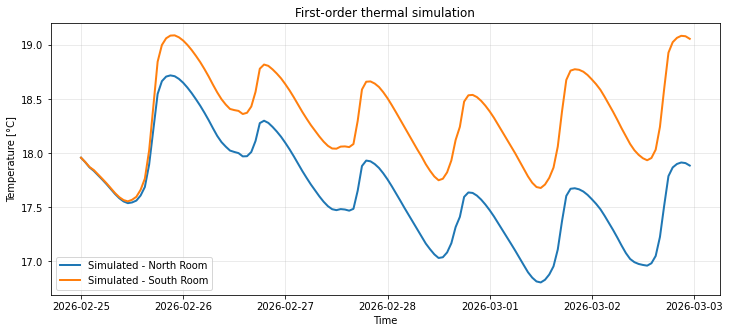

In [55]:
plt.figure(figsize=(12, 5))
# plt.plot(df_sim.index, df_sim[column_in_north], label="Measured indoor - North Room", linewidth=2)
plt.plot(df_sim.index, df_sim["Tsim_baseline_north"], label="Simulated - North Room", linewidth=2)
plt.plot(df_sim.index, df_sim["Tsim_baseline_south"], label="Simulated - South Room", linewidth=2)

plt.title("First-order thermal simulation")
plt.xlabel("Time")
plt.ylabel("Temperature [°C]")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

## Interpreting Thermal Parameters

The estimated heat loss coefficients for the north-facing and south-facing rooms
are relatively similar.

However, similar parameters do not necessarily imply similar energy performance.

Actual heat losses depend not only on intrinsic properties (k),
but also on operating conditions:

- Outdoor temperature differences
- Solar exposure
- Dynamic environmental effects

This means that two rooms with similar thermal coefficients
can still exhibit significantly different energy behavior.

### Structural vs Operational Effects

The similarity in thermal coefficients across rooms is expected,
as the building envelope is uniform.

However, differences in energy performance arise from external conditions:

- Exposure to lower outdoor temperatures (north-facing)
- Reduced solar gains
- Different thermal loading patterns

This highlights a key distinction:

The structure defines the potential for heat loss,
but environmental exposure determines actual energy performance.

### SECTION 4 — Define Scenarios 

We now explore how changes in thermal properties affect performance.

We simulate a hypothetical improvement in insulation.

In [60]:
k_improved_north = 0.8 * k_opt_north  # 20% improvement
k_improved_south = 0.8 * k_opt_south  # 20% improvement

In [61]:
df_sim["Tsim_improved_north"] = simulate_first_order_with_dynamic_solar(
    T0=T0,
    Tout_local_series=df_sim[column_out_north],
    Tout_north_series=df_sim[column_out_north],
    Tout_south_series=df_sim[column_out_south],
    k=k_improved_north,
    alpha=alpha_opt_north,  
    dt=dt
)

In [62]:
df_sim["Tsim_improved_south"] = simulate_first_order_with_dynamic_solar(
    T0=T0,
    Tout_local_series=df_sim[column_out_south],
    Tout_north_series=df_sim[column_out_north],
    Tout_south_series=df_sim[column_out_south],
    k=k_improved_south,
    alpha=alpha_opt_south,  
    dt=dt
)


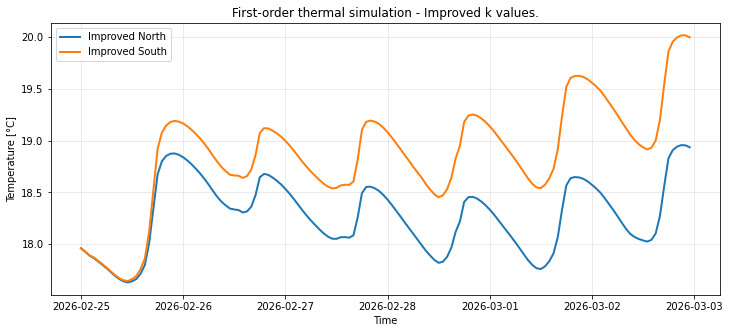

In [63]:
plt.figure(figsize=(12, 5))
# plt.plot(df_sim.index, df_sim["Tsim_baseline_north"], label="Baseline", color="red", linewidth=2)
plt.plot(df_sim.index, df_sim["Tsim_improved_north"], label="Improved North", linewidth=2)
plt.plot(df_sim.index, df_sim["Tsim_improved_south"], label="Improved South", linewidth=2)

plt.title("First-order thermal simulation - Improved k values.")
plt.xlabel("Time")
plt.ylabel("Temperature [°C]")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

### SECTION 6 — Quantification

Let's consider the following energy proxy - as we did in notebook _02_ua_estimation_ (Heat Loss Indicator):

## From Parameters to Energy Behavior

To better understand the real performance of each room,
we evaluate heat losses directly over time.

Instead of comparing parameters, we analyze:

- Instantaneous heat loss
- Accumulated (cumulative) heat loss

This provides a more realistic picture of where energy is actually being lost.

In [67]:
Tout_north = df_sim[column_out_north]
Tin_baseline_north = df_sim["Tsim_baseline_north"]
Tin_improved_north = df_sim["Tsim_improved_north"]

heat_loss_baseline_north = k_opt_north * (Tin_baseline_north - Tout_north)
heat_loss_improved_north = k_improved_north * (Tin_improved_north - Tout_north)

# cumulative difference
cumulative_saving_north = (heat_loss_baseline_north - heat_loss_improved_north).cumsum()
print(f"Cumulative savings based on defined energy proxy: {cumulative_saving_north.iloc[-1]}")

Cumulative savings based on defined energy proxy: 1.0538472390002624


#### Room Comparison

In [68]:
Tout_south = df_sim[column_out_south]
Tin_baseline_south = df_sim["Tsim_baseline_south"]
Tin_improved_south = df_sim["Tsim_improved_south"]

heat_loss_baseline_south = k_baseline_south * (Tin_baseline_south - Tout_south)
heat_loss_improved_south = k_improved_south * (Tin_improved_south - Tout_south)

cumulative_saving_south = (heat_loss_baseline_south - heat_loss_improved_south).cumsum()
print(f"Cumulative savings based on defined energy proxy: {cumulative_saving_south.iloc[-1]}")

Cumulative savings based on defined energy proxy: 0.9449587802686662


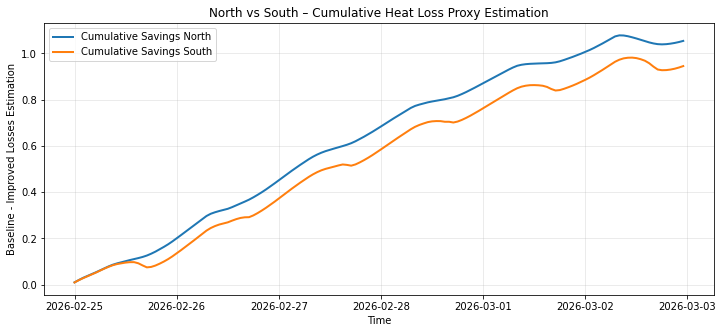

In [69]:
plt.figure(figsize=(12, 5))
plt.plot(df_sim.index, cumulative_saving_north, label="Cumulative Savings North", linewidth=2)
plt.plot(df_sim.index, cumulative_saving_south, label="Cumulative Savings South", linewidth=2)


plt.title("North vs South – Cumulative Heat Loss Proxy Estimation")
plt.xlabel("Time")
plt.ylabel("Baseline - Improved Losses Estimation")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [79]:
total_loss_baseline_north = heat_loss_baseline_north.sum()
total_loss_improved_north = heat_loss_improved_north.sum()

total_loss_baseline_south = heat_loss_baseline_south.sum()
total_loss_improved_south = heat_loss_improved_south.sum()

savings_abs_north = total_loss_baseline_north - total_loss_improved_north
savings_abs_south = total_loss_baseline_south - total_loss_improved_south

relative_gain_abs = savings_abs_north - savings_abs_south
improvement_ratio = savings_abs_north / savings_abs_south

print(f"Absolute savings (north): {savings_abs_north:.3f}")
print(f"Absolute savings (south): {savings_abs_south:.3f}")
print(f"Absolute gain advantage (north - south): {relative_gain_abs:.3f}")
print(f"North/South improvement ratio: {improvement_ratio:.3f}")

Absolute savings (north): 1.054
Absolute savings (south): 0.945
Absolute gain advantage (north - south): 0.109
North/South improvement ratio: 1.115


## Quantifying the Impact of a Targeted Intervention

A 20% reduction in the heat loss coefficient was simulated for both rooms.

As expected, the relative percentage improvement is similar in both cases, since the same proportional reduction in k was applied.

However, the more important metric is the absolute reduction in cumulative heat loss.

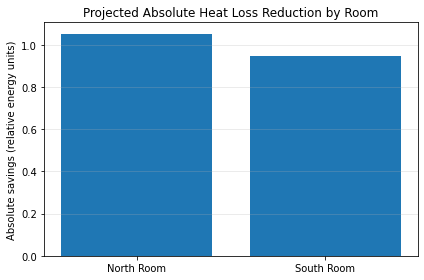

In [82]:
plt.figure(figsize=(6,4))
plt.bar(
    ['North Room', 'South Room'],
    [savings_abs_north, savings_abs_south]
)
plt.title("Projected Absolute Heat Loss Reduction by Room")
plt.ylabel("Absolute savings (relative energy units)")
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()

plt.savefig("../reports/figures/05_actionable_energy_insights/absolute_savings_comparison.png", dpi=300, facecolor='white')

## Absolute Savings Comparison

The north-facing room achieves a larger absolute reduction in cumulative heat loss.

In this simulation:

- the absolute savings advantage of the north-facing room is approximately **0.109 relative units**
- the north-facing room delivers about **1.12×** the benefit of the south-facing room for the same proportional intervention

This means that, even though both rooms improve by a similar percentage, the practical return is higher in the north-facing room.

In other words, the same intervention yields greater total benefit when applied to the more exposed zone.

## Interpretation

This result is consistent with the earlier observation that the thermal coefficients of the two rooms are similar, which is expected given the relatively uniform building envelope.

The difference does not come from the structure alone, but from the operating conditions:

- the north-facing room experiences less favorable outdoor exposure
- it benefits less from solar gains
- therefore, it accumulates greater thermal losses over time

As a consequence, reducing heat loss in the north-facing room produces a larger absolute payoff.

## Interpretation

This result is consistent with the earlier observation that the thermal coefficients of the two rooms are similar, which is expected given the relatively uniform building envelope.

The difference does not come from the structure alone, but from the operating conditions:

- the north-facing room experiences less favorable outdoor exposure
- it benefits less from solar gains
- therefore, it accumulates greater thermal losses over time

As a consequence, reducing heat loss in the north-facing room produces a larger absolute payoff.

## Next Steps

While this approach provides valuable insights,
there is still room to improve model accuracy and generalization.

In future work, we explore how data-driven techniques,
such as physics-informed machine learning,
can further enhance predictive performance.